<a href="https://colab.research.google.com/github/desaijay24/intrusion-detection-vanet-fl/blob/main/notebooks/non_iid_federated_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Uninstall potentially incompatible versions
!pip uninstall -y flwr numpy

# flwr>=1.10.0 is needed for compatibility with NumPy 2.0 (and Python 3.12).
!pip install -q numpy==2.0.0
!pip install -q 'flwr[simulation]>=1.10.0' tensorflow scikit-learn pandas

Mounted at /content/drive
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.0/19.0 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 752.9/752.9 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.4/71.4 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.7/251.7 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you h

In [ ]:
import flwr as fl
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score

# Uninstall numpy and related libraries that might have conflicting versions
# It's important to uninstall scipy explicitly to ensure a clean slate.
!pip uninstall -y numpy scikit-learn tensorflow scipy

# Install compatible numpy first
!pip install -q numpy==2.0.0

# Then install scipy, which should be able to resolve to a version compatible with numpy 2.0.0
!pip install -q scipy

# Then install scikit-learn, which depends on scipy and numpy
!pip install -q scikit-learn

# Finally, install tensorflow, which also depends on numpy
!pip install -q tensorflow

# Re-import numpy after re-installation
import numpy as np

Found existing installation: numpy 2.0.0
Uninstalling numpy-2.0.0:
  Successfully uninstalled numpy-2.0.0
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires scipy>=1.13, which is not installed.
missingno 0.5.2 requires scipy, which is not installed.
access 1.1.10.post3 requires scipy>=1.14.1, which is not installed.
plotnine 0.14.5 requires scipy>=1.8.0, which is not installed.
cvxpy 1.6.7 requires scipy>=1.11.0, which is not installed.
xgboost 3.1.3 requires scipy, which is not installed.

In [ ]:
X = pd.read_csv("/content/drive/MyDrive/UNSW_X_preprocessed.csv")
y = pd.read_csv("/content/drive/MyDrive/UNSW_y.csv")

# If y is a DF with one column
if y.shape[1] == 1:
    y = y.iloc[:, 0]

X = X.values.astype("float32")
y = y.values.astype("int32")

print(X.shape, y.shape)


(82332, 25) (82332,)


In [ ]:
X_train_all, X_test, y_train_all, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train_all.shape, "Test:", X_test.shape)


Train: (65865, 25) Test: (16467, 25)


In [ ]:
import numpy as np

def non_iid_dirichlet_split(X, y, num_clients=4, alpha=0.5):
    """
    Splits dataset into non-IID partitions using Dirichlet distribution.
    alpha < 1  => highly non-IID
    alpha > 1  => more IID
    """
    X = np.array(X)
    y = np.array(y)

    num_classes = len(np.unique(y))
    client_indices = [[] for _ in range(num_clients)]

    # Sample distribution for each class
    label_indices = [np.where(y == i)[0] for i in range(num_classes)]

    for c, indices in enumerate(label_indices):
        np.random.shuffle(indices)
        proportions = np.random.dirichlet(np.repeat(alpha, num_clients))
        proportions = (np.cumsum(proportions) * len(indices)).astype(int)[:-1]
        split_indices = np.split(indices, proportions)

        for client_id, idx in enumerate(split_indices):
            client_indices[client_id].extend(idx)

    # Convert into X, y for each client
    client_data = []
    for i in range(num_clients):
        client_X = X[client_indices[i]]
        client_y = y[client_indices[i]]
        client_data.append((client_X, client_y))

    return client_data

# --------------- RUN SPLIT ----------------
clients = non_iid_dirichlet_split(X, y, num_clients=4, alpha=0.5)

for i, (cx, cy) in enumerate(clients):
    print(f"Client {i}: X shape={cx.shape}, y distribution={np.bincount(cy)}")


Client 0: X shape=(5410, 25), y distribution=[ 781 4629]
Client 1: X shape=(33976, 25), y distribution=[33587   389]
Client 2: X shape=(6163, 25), y distribution=[1763 4400]
Client 3: X shape=(36783, 25), y distribution=[  869 35914]


In [ ]:
def create_model(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu', input_shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(2, activation='softmax')  # binary classification
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

input_dim = X.shape[1]


In [ ]:
class FedProxLoss(tf.keras.losses.Loss):
    def __init__(self, mu, global_weights):
        super().__init__()
        self.mu = mu
        self.global_weights = global_weights

    def call(self, y_true, y_pred):
        ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        prox = 0.0
        for w, w_global in zip(self.model.trainable_variables, self.global_weights):
            prox += tf.reduce_sum(tf.square(w - w_global))
        return ce + (self.mu / 2) * prox

In [ ]:
class FedProxClient(fl.client.NumPyClient):
    def __init__(self, X, y, mu=0.01):
        self.X = X
        self.y = y
        self.mu = mu
        self.model = create_model(X.shape[1])

    def get_parameters(self, config=None):
        return self.model.get_weights()

    def set_parameters(self, parameters):
        self.model.set_weights(parameters)
        self.global_weights = [tf.convert_to_tensor(w) for w in parameters]

    def fit(self, parameters, config=None):
        self.set_parameters(parameters)

        optimizer = tf.keras.optimizers.Adam(0.001)

        for epoch in range(10):
            with tf.GradientTape() as tape:
                logits = self.model(self.X, training=True)
                ce_loss = tf.keras.losses.sparse_categorical_crossentropy(self.y, logits)
                prox_loss = 0.0
                for w, w_global in zip(self.model.trainable_variables, self.global_weights):
                    prox_loss += tf.reduce_sum(tf.square(w - w_global))
                loss = tf.reduce_mean(ce_loss + (self.mu / 2) * prox_loss)

            grads = tape.gradient(loss, self.model.trainable_variables)
            optimizer.apply_gradients(zip(grads, self.model.trainable_variables))

        return self.get_parameters(), len(self.X), {}

    def evaluate(self, parameters, config=None):
        self.set_parameters(parameters)
        preds = np.argmax(self.model.predict(self.X), axis=1)
        acc = np.mean(preds == self.y)
        return 0.0, len(self.X), {"accuracy": acc}

In [ ]:
best_acc = 0
patience = 2
wait = 0

In [ ]:
'''def global_evaluate(server_round, parameters, config):
    global best_acc, wait

    model = create_model(X_test.shape[1])
    model.set_weights(parameters)
    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    if acc > best_acc:
        best_acc = acc
        wait = 0
    else:
        wait += 1

    if wait >= patience:
        print("Early stopping triggered at round", server_round)
        raise StopIteration

    return loss, {"accuracy": acc}'''

In [ ]:
NUM_CLIENTS = 4
strategy = fl.server.strategy.FedProx(
    proximal_mu=0.01,  # proximal strength, required by FedProx strategy
    min_fit_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    fraction_fit=1.0,
    #evaluate_fn=global_evaluate
)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

def evaluate_round(server_round, parameters, config):
    model = create_model(X_test.shape[1])
    model.set_weights(parameters)

    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n Round {server_round} Results")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")

    return 0.0, {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }


In [ ]:
def client_fn(cid):
    cid = int(cid)
    return FedProxClient(*clients[cid], mu=0.01)

history = fl.simulation.start_simulation(

    client_fn=client_fn,
    num_clients=4,
    config=fl.server.ServerConfig(num_rounds=10),
    strategy=strategy
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

          

  15/1062 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step    
  42/1062 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
  13/1150 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step    
  68/1062 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


(ClientAppActor pid=2272) [2026-02-07 13:56:14,966 E 2272 2388] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(ClientAppActor pid=2271) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`. [repeated 5x across cluster]
(ClientAppActor pid=2271) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=2271) 
(ClientAppActor pid=2271)             This is a deprecated feature. It will be removed
(ClientAppActor pid=2271)             entirely in future versi

  1/193 ━━━━━━━━━━━━━━━━━━━━ 16s 87ms/step
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step [repeated 78x across cluster]
 55/193 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


(ClientAppActor pid=2272) 
(ClientAppActor pid=2272)         


...

(ClientAppActor pid=2271) 
(ClientAppActor pid=2271)         


 15/170 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step   
 39/170 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
 61/170 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
 83/170 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
108/170 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
133/170 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
158/170 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
169/170 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


(ClientAppActor pid=2271) 
(ClientAppActor pid=2271)         


   1/1062 ━━━━━━━━━━━━━━━━━━━━ 2:56 166ms/step
 903/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step [repeated 56x across cluster]
  43/1062 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


INFO :      aggregate_evaluate: received 4 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 10 round(s) in 103.44s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.0
INFO :      		round 2: 0.0
INFO :      		round 3: 0.0
INFO :      		round 4: 0.0
INFO :      		round 5: 0.0
INFO :      		round 6: 0.0
INFO :      		round 7: 0.0
INFO :      		round 8: 0.0
INFO :      		round 9: 0.0
INFO :      		round 10: 0.0
INFO :      
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
global_model = create_model(X.shape[1])
global_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

# Load last round weights manually if needed
preds = np.argmax(global_model.predict(X), axis=1)
print(classification_report(y, preds))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2573/2573 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step
              precision    recall  f1-score   support

           0       0.40      0.37      0.39     37000
           1       0.52      0.54      0.53     45332

    accuracy                           0.47     82332
   macro avg       0.46      0.46      0.46     82332
weighted avg       0.46      0.47      0.46     82332



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

pred_probs = global_model.predict(X_test)
preds = np.argmax(pred_probs, axis=1)

print(classification_report(y_test, preds, digits=4))

acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds, zero_division=0)
rec = recall_score(y_test, preds, zero_division=0)
f1 = f1_score(y_test, preds, zero_division=0)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)

515/515 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           0     0.3958    0.3655    0.3800      7450
           1     0.5069    0.5390    0.5225      9017

    accuracy                         0.4605     16467
   macro avg     0.4514    0.4522    0.4513     16467
weighted avg     0.4566    0.4605    0.4580     16467

Accuracy: 0.4604967510779134
Precision: 0.5069364764785648
Recall: 0.5389819230342686
F1: 0.5224682863900236


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
results_df = pd.DataFrame(X_test, columns=[f"f{i}" for i in range(X_test.shape[1])])
results_df["true"] = y_test
results_df["pred"] = preds
results_df["action"] = results_df["pred"].apply(lambda x: "BLOCK" if x == 1 else "ALLOW")

blocked = results_df[results_df["action"] == "BLOCK"]
blocked_path = "/content/drive/MyDrive/UNSW_blocked_predictions_FL2.csv"
blocked.to_csv(blocked_path, index=False)

print(f"Blocked flows saved to: {blocked_path}")
print("Total blocked:", len(blocked))
print("True attacks blocked:", sum((results_df["true"]==1) & (results_df["action"]=="BLOCK")))
print("False blocks:", sum((results_df["true"]==0) & (results_df["action"]=="BLOCK")))


Blocked flows saved to: /content/drive/MyDrive/UNSW_blocked_predictions_FL2.csv
Total blocked: 9587
True attacks blocked: 4860
False blocks: 4727


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
!pip install seaborn matplotlib scikit-learn


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
import numpy as np

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


515/515 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


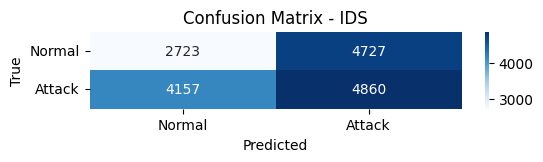

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
pred_probs_test = global_model.predict(X_test)
preds_test = np.argmax(pred_probs_test, axis=1)

cm = confusion_matrix(y_test, preds_test)

plt.figure(figsize=(6,1))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Attack"],
            yticklabels=["Normal", "Attack"])
plt.title("Confusion Matrix - IDS")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

515/515 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


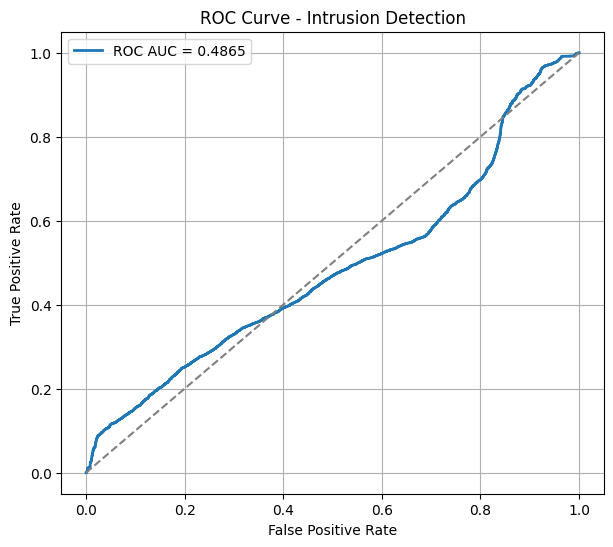

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
pred_probs = global_model.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, pred_probs[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, lw=2, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Intrusion Detection")
plt.legend()
plt.grid(True)
plt.show()

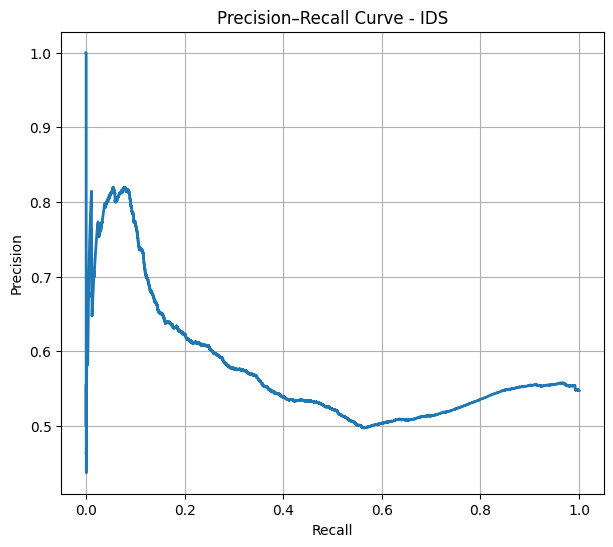

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, pred_probs[:,1])

plt.figure(figsize=(7,6))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - IDS")
plt.grid(True)
plt.show()


/tmp/ipython-input-2362512279.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=preds, palette="viridis")


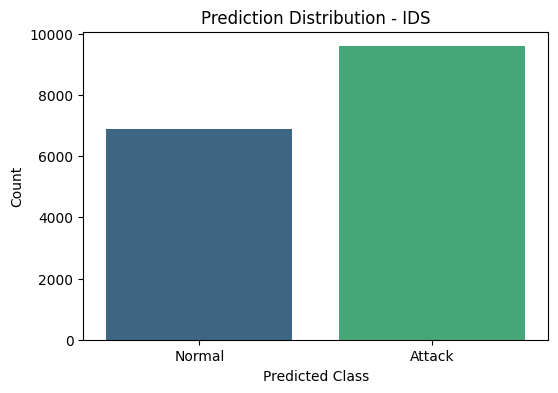

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=preds, palette="viridis")
plt.xticks([0,1], ["Normal", "Attack"])
plt.title("Prediction Distribution - IDS")
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.show()


/tmp/ipython-input-2518185046.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=results_df["action"], palette="magma")
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


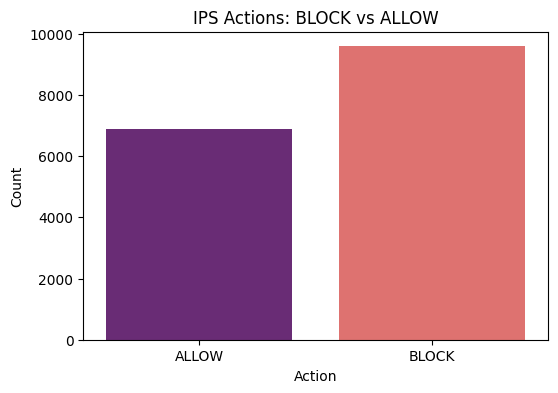

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=results_df["action"], palette="magma")
plt.title("IPS Actions: BLOCK vs ALLOW")
plt.xlabel("Action")
plt.ylabel("Count")
plt.show()


/tmp/ipython-input-2673397302.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=attack_df["action"], palette="coolwarm")


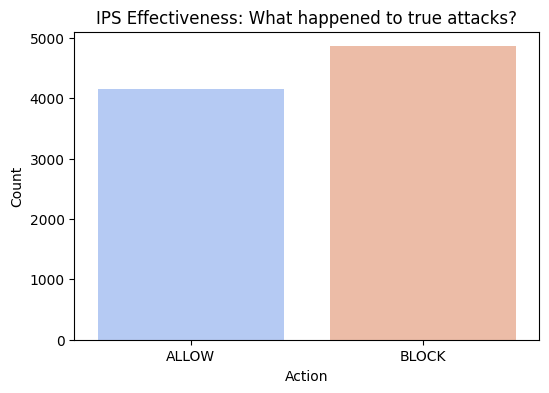

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
attack_df = results_df[results_df["true"] == 1]  # only attack samples

plt.figure(figsize=(6,4))
sns.countplot(x=attack_df["action"], palette="coolwarm")
plt.title("IPS Effectiveness: What happened to true attacks?")
plt.xlabel("Action")
plt.ylabel("Count")
plt.show()


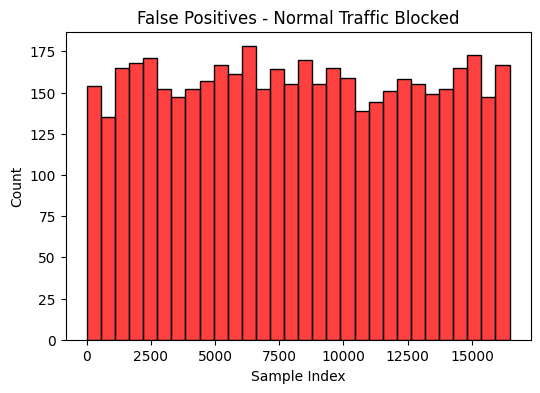

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
fp_df = results_df[(results_df["true"] == 0) & (results_df["pred"] == 1)]

plt.figure(figsize=(6,4))
sns.histplot(fp_df.index, bins=30, color="red")
plt.title("False Positives - Normal Traffic Blocked")
plt.xlabel("Sample Index")
plt.ylabel("Count")
plt.show()


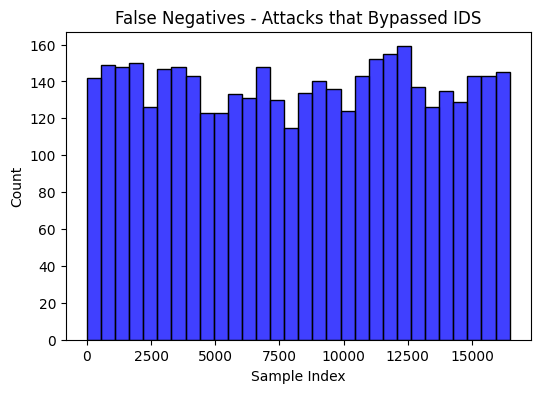

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
fn_df = results_df[(results_df["true"] == 1) & (results_df["pred"] == 0)]

plt.figure(figsize=(6,4))
sns.histplot(fn_df.index, bins=30, color="blue")
plt.title("False Negatives - Attacks that Bypassed IDS")
plt.xlabel("Sample Index")
plt.ylabel("Count")
plt.show()
